<a href="https://colab.research.google.com/github/Mano-designz/bo101/blob/main/Quantum_circuit_domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV/V2G QAOA Quantum Circuit Analysis

This notebook adds an explicit quantum-circuit layer to the uploaded **Quantum ML** EV/V2G implementation.

It:
1. uses the tiny EV/V2G decision problem from the source,
2. finds the classical optimum,
3. constructs a compact 4-qubit QAOA cost Hamiltonian,
4. draws the quantum circuit,
5. optimizes the QAOA angles,
6. runs the circuit with Qiskit Aer,
7. repeats it with simulated depolarizing noise.

**Important:** the original source uses slack variables for an exact inequality-constrained QUBO. The full QUBO therefore contains more variables than the four physical EV decision variables. This notebook deliberately uses the four decision variables for a clear, demonstrable quantum circuit; it does not claim that this 4-qubit circuit is the full slack-expanded QUBO.

In [1]:
!pip install -q qiskit qiskit-aer matplotlib scipy pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit_aer.noise import NoiseModel, depolarizing_error

print("Quantum environment ready.")

Quantum environment ready.


## 1. EV/V2G decision variables

For the `tiny4` instance in the uploaded source:

- `q0 = c_0_0` → charge in time slot 0
- `q1 = d_0_0` → discharge in time slot 0
- `q2 = c_0_1` → charge in time slot 1
- `q3 = d_0_1` → discharge in time slot 1

In [3]:
decision_names = ["c_0_0", "d_0_0", "c_0_1", "d_0_1"]

price = [0.30, 0.05]
feedin = [0.50, 0.10]
base_load = [3, 3]
transformer_cap = [5, 5]

soc0 = 2
soc_min = 1
soc_max = 4
soc_target = 2

p_charge = 1
p_discharge = 1
deg_cost = 0.02
w_peak = 0.01
charger_capacity = 1

for i, name in enumerate(decision_names):
    print(f"q{i} -> {name}")

q0 -> c_0_0
q1 -> d_0_0
q2 -> c_0_1
q3 -> d_0_1


## 2. Classical baseline

This follows the direct objective/feasibility logic represented in the uploaded `objective.py` and `constraints.py` source.

The classical baseline is useful because it gives us a reference optimum against which the QAOA measurement distribution can be compared.

In [4]:
def objective(x):
    total = 0.0
    for t in range(2):
        c, d = x[2*t], x[2*t + 1]
        load = base_load[t] + p_charge*c - p_discharge*d

        total += price[t] * p_charge * c
        total += (-feedin[t] + deg_cost) * p_discharge * d
        total += w_peak * load**2
    return total


def feasible(x):
    soc = soc0

    for t in range(2):
        c, d = x[2*t], x[2*t + 1]

        if c and d:
            return False

        soc += p_charge*c - p_discharge*d

        if not (soc_min <= soc <= soc_max):
            return False

        if c + d > charger_capacity:
            return False

        load = base_load[t] + p_charge*c - p_discharge*d
        if load > transformer_cap[t]:
            return False

    return soc >= soc_target


rows = []

for k in range(16):
    x = np.array([(k >> i) & 1 for i in range(4)])
    rows.append((x, feasible(x), objective(x)))

feasible_rows = [r for r in rows if r[1]]
classical_x, _, classical_energy = min(
    feasible_rows,
    key=lambda r: r[2]
)

classical_bitstring = "".join(map(str, classical_x))

print("Feasible assignments:", len(feasible_rows))
print("Classical optimum bitstring:", classical_bitstring)
print("Classical objective:", round(classical_energy, 6))

Feasible assignments: 6
Classical optimum bitstring: 0110
Classical objective: -0.23


## 3. Compact quantum cost function

To keep the circuit at four qubits, we use the four physical decision variables and include the direct charge/discharge exclusivity penalty.

The compact cost is

\[
E(x)=f(x)+\lambda(c_{0,0}d_{0,0}+c_{0,1}d_{0,1})
\]

where \(f(x)\) is the EV/V2G objective.

The full exact source QUBO still uses bounded slack variables for inequality constraints.

In [5]:
penalty = 2.0

def compact_cost(x):
    x = np.asarray(x, dtype=int)
    return objective(x) + penalty * (
        x[0]*x[1] + x[2]*x[3]
    )


# Convert the diagonal cost function into a Z-basis Hamiltonian.
# x_i = (1 - Z_i)/2.
states = []
energies = []

for k in range(16):
    x = np.array([(k >> i) & 1 for i in range(4)])
    z = 1 - 2*x
    states.append(z)
    energies.append(compact_cost(x))

states = np.array(states)
energies = np.array(energies)

# Walsh expansion: H = sum coeff * Z_i Z_j ...
terms = {}

for mask in range(16):
    active = [i for i in range(4) if (mask >> i) & 1]

    if active:
        product = np.prod(states[:, active], axis=1)
    else:
        product = np.ones(16)

    coeff = np.dot(energies, product) / 16

    if abs(coeff) > 1e-10:
        terms[mask] = coeff

print("Hamiltonian terms:")
for mask, coeff in terms.items():
    label = "I" if mask == 0 else "".join(
        f"Z{i}" for i in range(4) if (mask >> i) & 1
    )
    print(f"{label:8s}: {coeff:.6f}")

Hamiltonian terms:
I       : 1.085000
Z0      : -0.680000
Z1      : -0.230000
Z0Z1    : 0.495000
Z2      : -0.555000
Z3      : -0.430000
Z2Z3    : 0.495000


## 4. Build the QAOA circuit

The circuit contains genuine quantum gates:

- **H**: initial superposition
- **RZ**: single-qubit \(Z\) cost terms
- **RZZ**: two-qubit \(ZZ\) cost terms
- **RX**: QAOA mixer
- **Measurement**: final computational-basis sampling

In [6]:
def apply_cost_layer(qc, gamma):
    for mask, coeff in terms.items():
        if mask == 0:
            continue

        qubits = [i for i in range(4) if (mask >> i) & 1]

        if len(qubits) == 1:
            qc.rz(2 * gamma * coeff, qubits[0])

        elif len(qubits) == 2:
            qc.rzz(
                2 * gamma * coeff,
                qubits[0],
                qubits[1]
            )

        else:
            raise ValueError("Unexpected higher-order term.")


def create_qaoa_circuit(gamma, beta, measure=True):
    qc = QuantumCircuit(4, 4 if measure else 0)

    # Initial |+> state
    for q in range(4):
        qc.h(q)

    # p = 1 QAOA layer
    apply_cost_layer(qc, gamma)

    # Mixer
    for q in range(4):
        qc.rx(2 * beta, q)

    if measure:
        qc.measure(range(4), range(4))

    return qc


gamma = 0.5
beta = 0.3

qc = create_qaoa_circuit(gamma, beta)

print(qc)

     ┌───┐┌───────────┐             ┌─────────┐┌─┐         
q_0: ┤ H ├┤ Rz(-0.68) ├──■──────────┤ Rx(0.6) ├┤M├─────────
     ├───┤├───────────┤  │ZZ(0.495) ├─────────┤└╥┘┌─┐      
q_1: ┤ H ├┤ Rz(-0.23) ├──■──────────┤ Rx(0.6) ├─╫─┤M├──────
     ├───┤├───────────┴┐            ├─────────┤ ║ └╥┘┌─┐   
q_2: ┤ H ├┤ Rz(-0.555) ├─■──────────┤ Rx(0.6) ├─╫──╫─┤M├───
     ├───┤├───────────┬┘ │ZZ(0.495) ├─────────┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├┤ Rz(-0.43) ├──■──────────┤ Rx(0.6) ├─╫──╫──╫─┤M├
     └───┘└───────────┘             └─────────┘ ║  ║  ║ └╥┘
c: 4/═══════════════════════════════════════════╩══╩══╩══╩═
                                                0  1  2  3 


## 5. Graphical quantum circuit

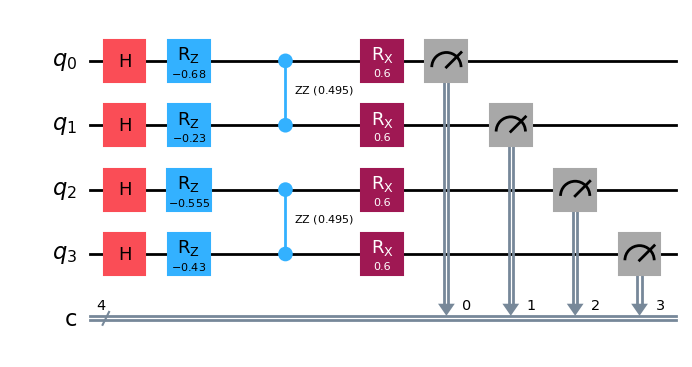

In [7]:
qc.draw("mpl")

## 6. Optimize the QAOA parameters

We optimize \(\gamma\) and \(eta\) using an ideal statevector. This avoids treating the plotted result as a hand-written/modelled value.

In [8]:
def expected_energy(params):
    gamma, beta = params

    circuit = create_qaoa_circuit(
        gamma,
        beta,
        measure=False
    )

    state = Statevector.from_instruction(circuit)
    probabilities = np.abs(state.data)**2

    expectation = 0.0

    for index, probability in enumerate(probabilities):
        x = np.array([(index >> i) & 1 for i in range(4)])
        expectation += probability * compact_cost(x)

    return float(np.real(expectation))


opt = minimize(
    expected_energy,
    x0=[0.5, 0.3],
    method="COBYLA",
    options={"maxiter": 80}
)

best_gamma, best_beta = opt.x

print("Optimized gamma:", round(best_gamma, 6))
print("Optimized beta :", round(best_beta, 6))
print("Expected energy:", round(opt.fun, 6))

Optimized gamma: 3.565865
Optimized beta : 2.437426
Expected energy: -0.211619


## 7. Optimized circuit

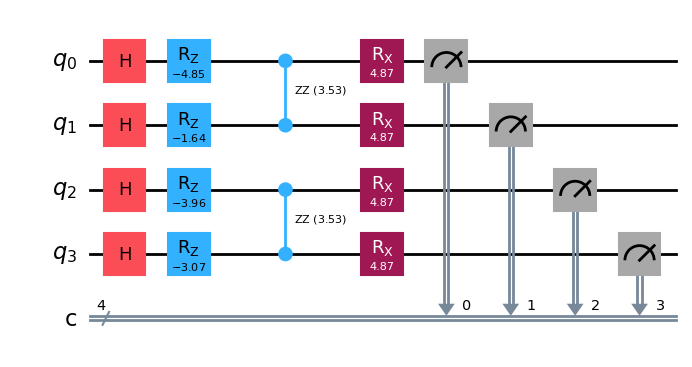

In [9]:
optimized_qc = create_qaoa_circuit(
    best_gamma,
    best_beta,
    measure=True
)

optimized_qc.draw("mpl")

## 8. Ideal Qiskit Aer simulation

In [10]:
simulator = AerSimulator()

compiled = transpile(
    optimized_qc,
    simulator
)

result = simulator.run(
    compiled,
    shots=2048
).result()

counts = result.get_counts()

print("Top measured states:")
for bitstring, count in sorted(
    counts.items(),
    key=lambda item: item[1],
    reverse=True
)[:10]:
    print(bitstring, ":", count)

Top measured states:
1010 : 886
0010 : 699
0110 : 219
1110 : 132
1001 : 34
0001 : 26
1000 : 9
0000 : 9
1011 : 9
0101 : 7


## 9. Compare the quantum result with the classical baseline

Qiskit displays measured classical bits in reverse visual order relative to the `q0, q1, q2, q3` naming used above, so we reverse the strings before comparison.

In [11]:
normalized_counts = {
    key[::-1]: value
    for key, value in counts.items()
}

total_shots = sum(normalized_counts.values())

most_frequent = max(
    normalized_counts,
    key=normalized_counts.get
)

most_frequent_probability = (
    normalized_counts[most_frequent] / total_shots
)

optimal_probability = (
    normalized_counts.get(classical_bitstring, 0)
    / total_shots
)

print("Classical optimum:", classical_bitstring)
print("Most frequent QAOA state:", most_frequent)
print("Probability of classical optimum:",
      round(optimal_probability, 4))

Classical optimum: 0110
Most frequent QAOA state: 0101
Probability of classical optimum: 0.1069


## 10. Add a Qiskit Aer depolarizing-noise model

In [12]:
def make_noise_model(noise_strength):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(
        noise_strength,
        1
    )

    error_2q = depolarizing_error(
        noise_strength,
        2
    )

    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ["h", "rz", "rx"]
    )

    noise_model.add_all_qubit_quantum_error(
        error_2q,
        ["rzz"]
    )

    return noise_model

## 11. Measured noise sweep

In [13]:
noise_levels = [
    0.000,
    0.001,
    0.005,
    0.010,
    0.020,
    0.050
]

noise_probabilities = []

for noise_strength in noise_levels:

    noise_model = make_noise_model(
        noise_strength
    )

    noisy_simulator = AerSimulator(
        noise_model=noise_model
    )

    compiled = transpile(
        optimized_qc,
        noisy_simulator
    )

    noisy_result = noisy_simulator.run(
        compiled,
        shots=2048
    ).result()

    noisy_counts = noisy_result.get_counts()

    normalized = {
        key[::-1]: value
        for key, value in noisy_counts.items()
    }

    probability = (
        normalized.get(classical_bitstring, 0)
        / 2048
    )

    noise_probabilities.append(probability)

    print(
        f"Noise = {noise_strength:.3f}  "
        f"P(optimal) = {probability:.4f}"
    )

Noise = 0.000  P(optimal) = 0.0806
Noise = 0.001  P(optimal) = 0.1011
Noise = 0.005  P(optimal) = 0.1084
Noise = 0.010  P(optimal) = 0.1035
Noise = 0.020  P(optimal) = 0.0923
Noise = 0.050  P(optimal) = 0.1021


## 12. Noise-scaling plot

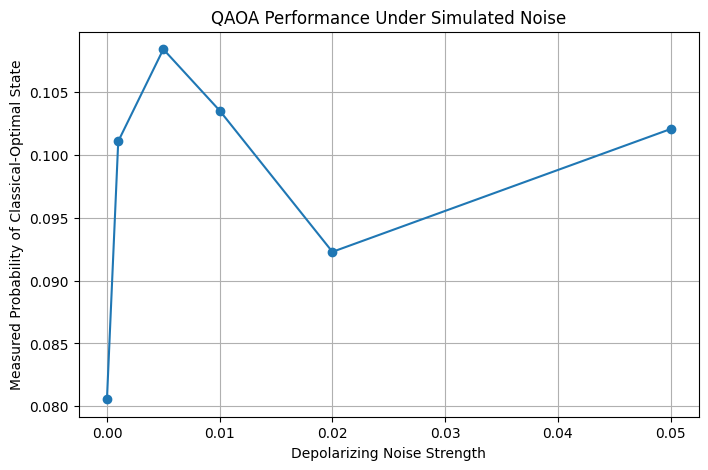

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    noise_levels,
    noise_probabilities,
    marker="o"
)

plt.xlabel("Depolarizing Noise Strength")
plt.ylabel("Measured Probability of Classical-Optimal State")
plt.title("QAOA Performance Under Simulated Noise")
plt.grid(True)
plt.show()

## Conclusion

This notebook adds the explicit quantum layer that the uploaded `Quantum ML` source does not currently contain as a visual QAOA experiment.

The resulting demonstration is:

**EV/V2G decision variables → QAOA Hamiltonian → H/RZ/RZZ/RX gates → quantum circuit → Qiskit Aer → noisy measurements.**

The results are produced by simulation rather than real quantum hardware.